# H100 campaign analysis

In-depth analysis of the completed 32-cell H100 campaign: eight
initialization arms (random / optical / SAR / ImageNet, in a ViT-B/16 and a
ConvNeXt-V2-Base track) at four nested label budgets, with once-scored
held-out TEST results for every cell.

**Provenance discipline.** Every number in this notebook flows through
`src.analysis.heldout_results.validate_evidence`, the same fail-closed
validator the report generator uses: completion markers must hash to their
cohort bindings, metrics must be TP/FP/FN-consistent, best-dev values must
equal the training-curve maximum, and TEST results must rebuild exactly from
the frozen cohort. A tampered byte anywhere in `results/h100/evidence/`
stops this notebook in the first cell.

Run from the repository root.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analysis.heldout_results import (
    ROLE_COLOR,
    ROLE_LABEL,
    ROLE_MARKER,
    ROLE_ORDER,
    TRACK_LABEL,
    validate_evidence,
)

REPO = Path.cwd()
assert (REPO / "results/h100/evidence").is_dir(), "run from the repository root"

validated = validate_evidence(
    REPO / "results/h100/evidence",
    arms_config=REPO / "configs/arms.yaml",
    detector_config=REPO / "configs/detector.yaml",
    splits_config=REPO / "data/splits.json",
)
campaign = validated["campaign"]
print(
    f"validated: {len(validated['cells'])} cells, "
    f"{len(validated['test_results'])} test results, "
    f"{campaign['gpu_hours']:.1f} GPU-hours on {campaign['hardware']}"
)

validated: 32 cells, 32 test results, 555.8 GPU-hours on NVIDIA H100 80GB HBM3


## The tidy cell table

One row per cell: identity, development selection (F1/precision/recall at
the checkpoint-bound threshold), execution facts, held-out TEST metrics, and
the dev-to-test shrinkage.

In [2]:
rows = []
for exp_id, cell in validated["cells"].items():
    test = validated["test_results"][exp_id]
    rows.append(
        {
            "exp_id": exp_id,
            "track": cell["track"],
            "role": cell["role"],
            "frac": cell["label_fraction"],
            "scenes": {10: 12, 25: 28, 50: 56, 100: 111}[cell["label_fraction"]],
            "dev_f1": cell["dev_f1"],
            "dev_p": cell["dev_precision"],
            "dev_r": cell["dev_recall"],
            "threshold": cell["threshold"],
            "best_epoch": cell["best_epoch"],
            "epochs_run": cell["epochs_run"],
            "gpu_h": cell["gpu_hours"],
            "test_f1": test["f1"],
            "test_p": test["precision"],
            "test_r": test["recall"],
        }
    )
df = pd.DataFrame(rows).sort_values(["track", "role", "frac"]).reset_index(drop=True)
df["gap"] = df["dev_f1"] - df["test_f1"]
df.round(4)

,exp_id,track,role,frac,scenes,dev_f1,dev_p,dev_r,threshold,best_epoch,epochs_run,gpu_h,test_f1,test_p,test_r,gap
0,cnnrand-f10-s0,cnn,floor,10,12,0.7992,0.8221,0.7776,0.7163,29,50,7.0388,0.6571,0.6866,0.6300,0.1421
1,cnnrand-f25-s0,cnn,floor,25,28,0.8167,0.8191,0.8143,0.8193,44,50,14.1505,0.7065,0.7284,0.6858,0.1102
2,cnnrand-f50-s0,cnn,floor,50,56,0.8664,0.8802,0.8530,0.8569,44,50,26.5766,0.7807,0.8157,0.7485,0.0857
3,cnnrand-f100-s0,cnn,floor,100,111,0.8919,0.9062,0.8781,0.9102,49,50,51.3535,0.8124,0.8535,0.7751,0.0795
4,cnnin1k-f10-s0,cnn,imagenet,10,12,0.8856,0.8953,0.8762,0.8687,4,25,3.4350,0.7810,0.8839,0.6996,0.1046
5,cnnin1k-f25-s0,cnn,imagenet,25,28,0.9005,0.8829,0.9188,0.9062,39,50,13.9843,0.8481,0.8456,0.8506,0.0524
6,cnnin1k-f50-s0,cnn,imagenet,50,56,0.9221,0.9065,0.9381,0.8989,19,40,21.1533,0.8807,0.8458,0.9185,0.0414
7,cnnin1k-f100-s0,cnn,imagenet,100,111,0.9387,0.9298,0.9478,0.8940,44,50,51.2396,0.8966,0.8788,0.9150,0.0421
8,beS2-f10-s0,cnn,optical,10,12,0.7992,0.8309,0.7698,0.7490,29,50,6.7873,0.6712,0.7105,0.6361,0.1280
9,beS2-f25-s0,cnn,optical,25,28,0.8063,0.8158,0.7969,0.8218,44,50,14.1040,0.7024,0.7188,0.6867,0.1039


## Development and TEST matrices

The paper's Table 3 (development) beside its held-out counterpart.

In [3]:
for metric in ("dev_f1", "test_f1"):
    pivot = df.pivot_table(index=["track", "role"], columns="frac", values=metric)
    pivot = pivot.reindex(
        [(t, r) for t in ("vit", "cnn") for r in ROLE_ORDER]
    )
    print(f"=== {metric} ===")
    print(pivot.round(4).to_string())
    print()

=== dev_f1 ===
frac               10      25      50      100
track role                                    
vit   floor     0.8030  0.8563  0.8912  0.8958
      optical   0.8902  0.8802  0.9136  0.9268
      sar       0.8857  0.8624  0.9161  0.9289
      imagenet  0.8761  0.8716  0.9284  0.9399
cnn   floor     0.7992  0.8167  0.8664  0.8919
      optical   0.7992  0.8063  0.8586  0.8636
      sar       0.8762  0.8868  0.8998  0.9068
      imagenet  0.8856  0.9005  0.9221  0.9387

=== test_f1 ===
frac               10      25      50      100
track role                                    
vit   floor     0.7042  0.7372  0.8101  0.8101
      optical   0.8198  0.8279  0.8495  0.8465
      sar       0.8041  0.7715  0.8672  0.8748
      imagenet  0.8103  0.8051  0.8545  0.8569
cnn   floor     0.6571  0.7065  0.7807  0.8124
      optical   0.6712  0.7024  0.7616  0.7948
      sar       0.8000  0.8025  0.8521  0.8221
      imagenet  0.7810  0.8481  0.8807  0.8966



## Label-efficiency curves: development beside held-out

The report shows the development curves; the held-out curves tell the same
scarcity story at uniformly lower values, with one structural difference in
the CNN-SAR arm at full data (Sect. 6 below).

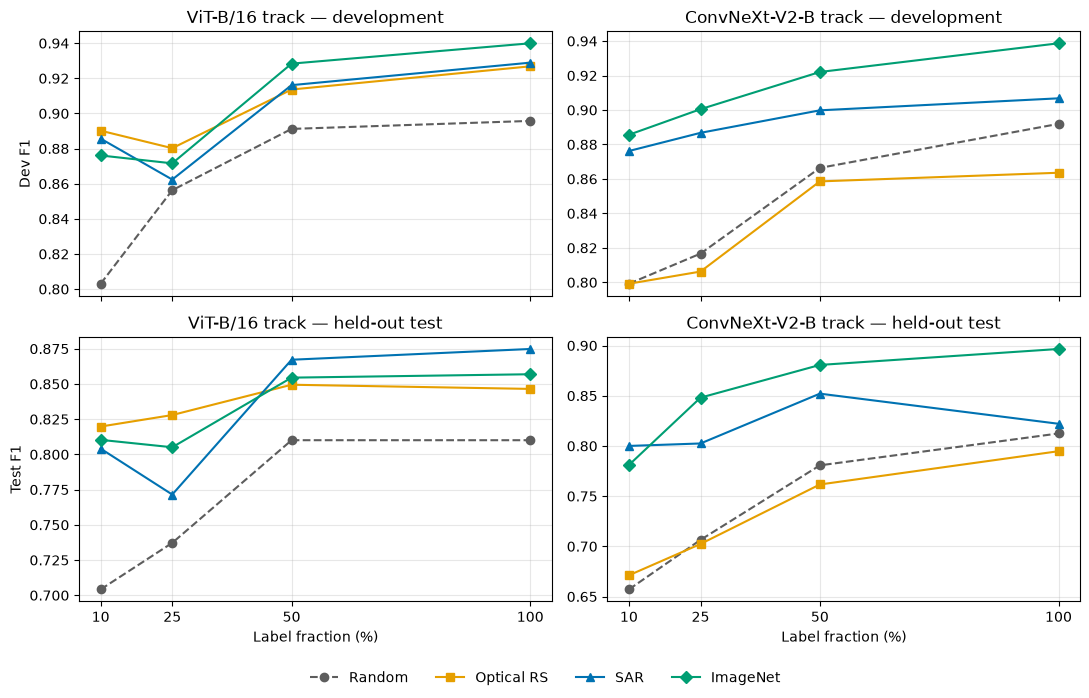

In [4]:
FRACS = [10, 25, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for row_i, metric in enumerate(("dev_f1", "test_f1")):
    for col_i, track in enumerate(("vit", "cnn")):
        ax = axes[row_i][col_i]
        for role in ROLE_ORDER:
            sub = df[(df.track == track) & (df.role == role)].sort_values("frac")
            ax.plot(
                sub.frac, sub[metric],
                color=ROLE_COLOR[role], marker=ROLE_MARKER[role],
                linestyle="--" if role == "floor" else "-",
                label=ROLE_LABEL[role] if (row_i, col_i) == (0, 0) else None,
            )
        ax.set_title(f"{TRACK_LABEL[track]} — {'development' if metric=='dev_f1' else 'held-out test'}")
        ax.set_xticks(FRACS)
        ax.grid(alpha=0.3)
axes[1][0].set_xlabel("Label fraction (%)"); axes[1][1].set_xlabel("Label fraction (%)")
axes[0][0].set_ylabel("Dev F1"); axes[1][0].set_ylabel("Test F1")
fig.legend(loc="lower center", ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## Dev-to-test shrinkage

Every cell shrinks. The question is whether shrinkage is uniform noise or
carries structure.

In [5]:
print(df.gap.describe().round(4).to_string())
print()
print("by track:")
print(df.groupby("track").gap.agg(["mean", "min", "max"]).round(4).to_string())
print()
print("by role:")
print(df.groupby("role").gap.agg(["mean", "min", "max"]).round(4).to_string())
print()
print("by fraction:")
print(df.groupby("frac").gap.agg(["mean", "min", "max"]).round(4).to_string())

count    32.0000
mean      0.0802
std       0.0246
min       0.0414
25%       0.0653
50%       0.0807
75%       0.0924
max       0.1421

by track:
         mean     min     max
track                        
cnn    0.0843  0.0414  0.1421
vit    0.0760  0.0489  0.1191

by role:
            mean     min     max
role                            
floor     0.1003  0.0795  0.1421
imagenet  0.0662  0.0414  0.1046
optical   0.0831  0.0523  0.1280
sar       0.0710  0.0477  0.0909

by fraction:
        mean     min     max
frac                        
10    0.0959  0.0657  0.1421
25    0.0849  0.0523  0.1191
50    0.0675  0.0414  0.0970
100   0.0723  0.0421  0.0857


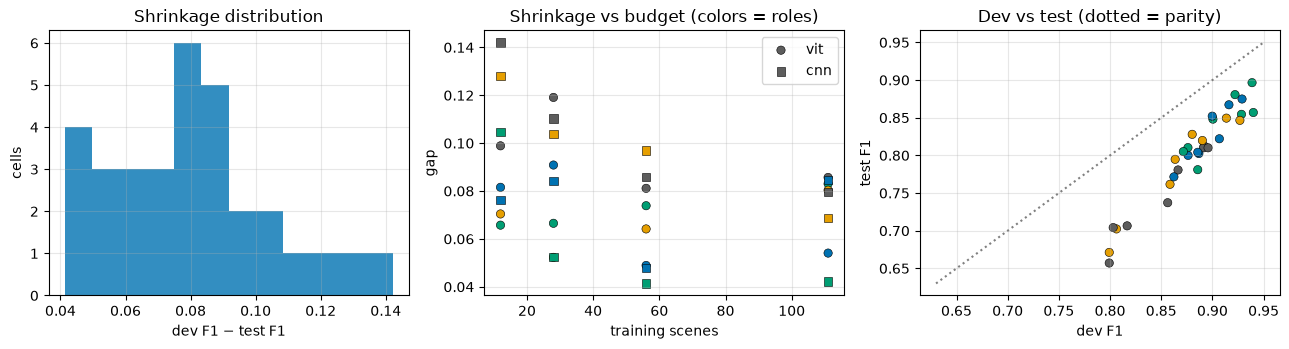

gap           1.000
scenes       -0.346
threshold    -0.499
dev_f1       -0.747
epochs_run   -0.081


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(df.gap, bins=12, color="#0072B2", alpha=0.8)
axes[0].set_xlabel("dev F1 − test F1"); axes[0].set_ylabel("cells")
axes[0].set_title("Shrinkage distribution")

for track, marker in (("vit", "o"), ("cnn", "s")):
    sub = df[df.track == track]
    axes[1].scatter(sub.scenes, sub.gap, marker=marker, label=track,
                    c=[ROLE_COLOR[r] for r in sub.role], edgecolors="black", linewidths=0.4)
axes[1].set_xlabel("training scenes"); axes[1].set_ylabel("gap")
axes[1].set_title("Shrinkage vs budget (colors = roles)")
axes[1].legend()

axes[2].scatter(df.dev_f1, df.test_f1, c=[ROLE_COLOR[r] for r in df.role],
                marker="o", edgecolors="black", linewidths=0.4)
lims = [0.63, 0.95]
axes[2].plot(lims, lims, ":", color="gray")
axes[2].set_xlabel("dev F1"); axes[2].set_ylabel("test F1")
axes[2].set_title("Dev vs test (dotted = parity)")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

corr = df[["gap", "scenes", "threshold", "dev_f1", "epochs_run"]].corr().round(3)
print(corr.gap.to_string())

The shrinkage is largest at the smallest budgets (scarce-label cells
overfit their eight development scenes hardest) and shrinks as data grows —
exactly the selection-optimism signature. It correlates negatively with
budget and dev F1, not with the threshold itself: the sweep is not the
problem; the eight-scene selection support is.

## Registered contrasts under both metrics

Transfer gain over the track floor (Eq. 2) and the SAR-minus-optical
contrast (Eq. 3), evaluated on development and on the held-out test split.

In [7]:
def value(track, role, frac, metric):
    return df[(df.track == track) & (df.role == role) & (df.frac == frac)][metric].item()

records = []
for track in ("vit", "cnn"):
    for frac in FRACS:
        for metric in ("dev_f1", "test_f1"):
            floor = value(track, "floor", frac, metric)
            records.append(
                {
                    "track": track, "frac": frac,
                    "metric": "dev" if metric == "dev_f1" else "test",
                    "optical_gain": value(track, "optical", frac, metric) - floor,
                    "sar_gain": value(track, "sar", frac, metric) - floor,
                    "imagenet_gain": value(track, "imagenet", frac, metric) - floor,
                    "sar_minus_optical": value(track, "sar", frac, metric)
                    - value(track, "optical", frac, metric),
                }
            )
contrasts = pd.DataFrame(records)
print(contrasts.round(4).to_string(index=False))
signs_agree = (
    (contrasts.pivot_table(index=["track", "frac"], columns="metric", values="sar_minus_optical") > 0)
    .agg(lambda r: r.dev == r.test, axis=1)
    .all()
)
print()
print("SAR−optical sign identical on dev and test at every (track, fraction):", bool(signs_agree))

track  frac metric  optical_gain  sar_gain  imagenet_gain  sar_minus_optical
  vit    10    dev        0.0872    0.0826         0.0730            -0.0045
  vit    10   test        0.1156    0.0999         0.1062            -0.0157
  vit    25    dev        0.0239    0.0061         0.0153            -0.0179
  vit    25   test        0.0907    0.0343         0.0679            -0.0564
  vit    50    dev        0.0224    0.0249         0.0372             0.0025
  vit    50   test        0.0394    0.0571         0.0444             0.0177
  vit   100    dev        0.0311    0.0332         0.0442             0.0021
  vit   100   test        0.0364    0.0648         0.0468             0.0283
  cnn    10    dev       -0.0000    0.0770         0.0864             0.0770
  cnn    10   test        0.0141    0.1429         0.1239             0.1288
  cnn    25    dev       -0.0104    0.0701         0.0838             0.0805
  cnn    25   test       -0.0041    0.0960         0.1416             0.1001

The SAR−optical sign is identical under both metrics at every
(track, fraction): negative in the ViT track below half data, positive
everywhere else. The paper's architecture-dependence claim does not rest on
selection noise.

## The full-data ranking flip

Development selection picks ImageNet as the full-data winner in both
tracks. Held-out scoring picks SAR in the ViT track.

In [8]:
for track in ("vit", "cnn"):
    sub = df[(df.track == track) & (df.frac == 100)]
    dev_order = sub.sort_values("dev_f1", ascending=False)[["role", "dev_f1"]]
    test_order = sub.sort_values("test_f1", ascending=False)[["role", "test_f1"]]
    print(f"=== {TRACK_LABEL[track]} at 100% ===")
    print("dev ranking: ", list(dev_order.itertuples(index=False, name=None)))
    print("test ranking:", list(test_order.itertuples(index=False, name=None)))
    print()

=== ViT-B/16 track at 100% ===
dev ranking:  [('imagenet', 0.9399428026692088), ('sar', 0.928919182083739), ('optical', 0.926829268292683), ('floor', 0.8957528957528957)]
test ranking: [('sar', 0.8748419721871049), ('imagenet', 0.8569072164948452), ('optical', 0.8464929859719439), ('floor', 0.8100810081008102)]

=== ConvNeXt-V2-B track at 100% ===
dev ranking:  [('imagenet', 0.9386973180076628), ('sar', 0.9067713444553483), ('floor', 0.8919449901768173), ('optical', 0.8635917566241413)]
test ranking: [('imagenet', 0.896551724137931), ('sar', 0.8220689655172414), ('floor', 0.8124156545209178), ('optical', 0.7947524333474397)]



## Monotonicity under both metrics

The campaign's grid gate stops on any arm whose test-F1 curve drops by more
than 0.02 between adjacent budgets. Two arms trip it, both in the SAR role
— and one of them (CNN-SAR) is invisible on development.

In [9]:
TOL = 0.02
print(f"{'arm':16s} {'metric':6s} {'transition':12s} {'drop':>8s}")
for track in ("vit", "cnn"):
    for role in ROLE_ORDER:
        for metric in ("dev_f1", "test_f1"):
            sub = df[(df.track == track) & (df.role == role)].sort_values("frac")
            values = sub[metric].to_list()
            for i in range(1, 4):
                drop = values[i] - values[i - 1]
                if drop < -TOL:
                    print(
                        f"{track}-{role:10s} {metric[:4]:6s} "
                        f"f{FRACS[i-1]}->f{FRACS[i]:<8d} {drop:+.4f}"
                    )

arm              metric transition       drop
vit-sar        dev_   f10->f25       -0.0233
vit-sar        test   f10->f25       -0.0326
cnn-sar        test   f50->f100      -0.0300


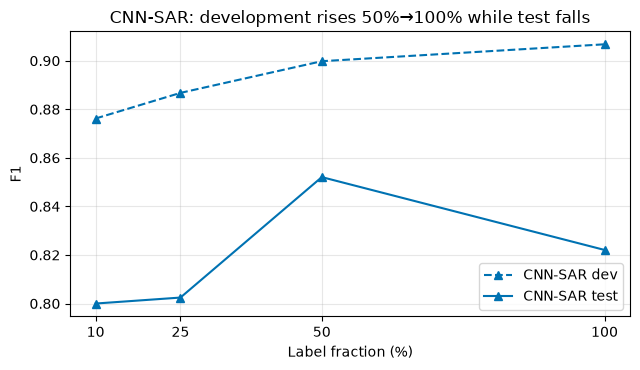

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for metric, style in (("dev_f1", "--"), ("test_f1", "-")):
    sub = df[(df.track == "cnn") & (df.role == "sar")].sort_values("frac")
    ax.plot(sub.frac, sub[metric], style, marker="^", color=ROLE_COLOR["sar"],
            label=f"CNN-SAR {'dev' if metric=='dev_f1' else 'test'}")
ax.set_xticks(FRACS)
ax.set_xlabel("Label fraction (%)"); ax.set_ylabel("F1")
ax.set_title("CNN-SAR: development rises 50%→100% while test falls")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Operating-point movement from dev to test

Each arrow starts at a cell's development (recall, precision) and ends at
its held-out test position. The movement is dominated by recall loss, not
precision loss: frozen thresholds transfer conservatively.

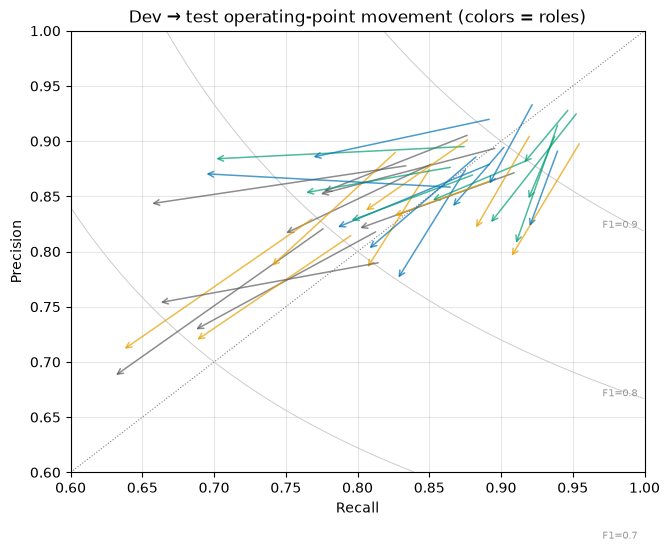

mean precision change dev->test: -0.0667
mean recall change dev->test:    -0.0898


In [11]:
fig, ax = plt.subplots(figsize=(6.8, 5.6))
for _, row in df.iterrows():
    ax.annotate(
        "", xy=(row.test_r, row.test_p), xytext=(row.dev_r, row.dev_p),
        arrowprops=dict(arrowstyle="->", color=ROLE_COLOR[row.role], alpha=0.7, lw=1.1),
    )
lims = [0.6, 1.0]
ax.plot(lims, lims, ":", color="gray", lw=0.8)
for iso in (0.7, 0.8, 0.9):
    r = np.linspace(0.55, 0.999, 200)
    prec = iso * r / np.clip(2 * r - iso, 1e-6, None)
    mask = (prec >= 0.6) & (prec <= 1.0) & (2 * r > iso)
    ax.plot(r[mask], prec[mask], color="#CCCCCC", lw=0.7)
    ax.text(0.995, iso * 0.995 / (2 * 0.995 - iso), f"F1={iso}", fontsize=7,
            color="#999999", ha="right")
ax.set_xlim(0.6, 1.0); ax.set_ylim(0.6, 1.0)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Dev → test operating-point movement (colors = roles)")
ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

delta_p = (df.test_p - df.dev_p).mean()
delta_r = (df.test_r - df.dev_r).mean()
print(f"mean precision change dev->test: {delta_p:+.4f}")
print(f"mean recall change dev->test:    {delta_r:+.4f}")

## Cost and value

Scarce-label cells carry the study's headline contrasts and are also its
cheapest. Held-out F1 per GPU-hour makes the point directly.

        exp_id  scenes  gpu_h  test_f1  test_f1_per_gpu_h
 sarmae-f10-s0      12 2.1974   0.8041             0.3659
cnnin1k-f10-s0      12 3.4350   0.7810             0.2274
vitrand-f10-s0      12 3.4880   0.7042             0.2019
vitin1k-f10-s0      12 4.1582   0.8103             0.1949
satdino-f10-s0      12 4.3085   0.8198             0.1903
 sarmae-f25-s0      28 4.1188   0.7715             0.1873
   beS1-f10-s0      12 6.6784   0.8000             0.1198
satdino-f25-s0      28 7.2908   0.8279             0.1136


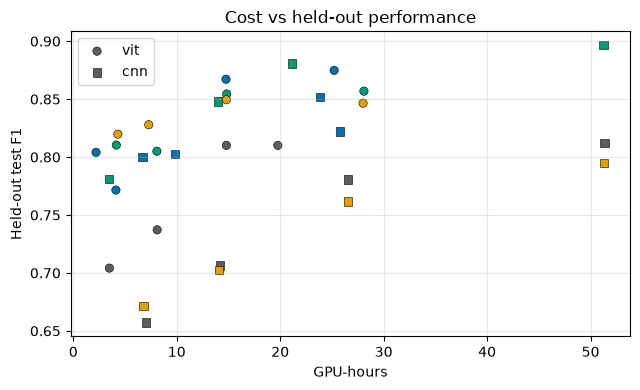

In [12]:
df["test_f1_per_gpu_h"] = df.test_f1 / df.gpu_h
best_value = df.sort_values("test_f1_per_gpu_h", ascending=False).head(8)
print(best_value[["exp_id", "scenes", "gpu_h", "test_f1", "test_f1_per_gpu_h"]]
      .round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4))
for track, marker in (("vit", "o"), ("cnn", "s")):
    sub = df[df.track == track]
    ax.scatter(sub.gpu_h, sub.test_f1, marker=marker,
               c=[ROLE_COLOR[r] for r in sub.role],
               edgecolors="black", linewidths=0.4, label=track)
ax.set_xlabel("GPU-hours"); ax.set_ylabel("Held-out test F1")
ax.set_title("Cost vs held-out performance")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Training-curve deep dive

From the committed per-cell `metrics.csv`: how quickly each arm reaches 95%
of its final best development F1, and which cells peaked in the very first
evaluation (epoch 4).

In [13]:
speed_rows = []
for exp_id, cell in validated["cells"].items():
    curve = pd.read_csv(REPO / "results/h100/evidence" / exp_id / "metrics.csv")
    curve = curve[curve.dev_f1.notna()][["epoch", "dev_f1"]]
    best = curve.dev_f1.max()
    reach = curve[curve.dev_f1 >= 0.95 * best].epoch.min()
    speed_rows.append(
        {
            "exp_id": exp_id, "track": cell["track"], "role": cell["role"],
            "frac": cell["label_fraction"], "evals": len(curve),
            "epoch_95pct": int(reach), "best_epoch": cell["best_epoch"],
        }
    )
speed = pd.DataFrame(speed_rows)
print("cells whose best checkpoint is the FIRST evaluation (epoch 4):")
print(speed[speed.best_epoch == 4][["exp_id", "track", "role", "frac"]]
      .to_string(index=False))
print()
print("median epoch to reach 95% of best dev F1, by track and role:")
print(speed.groupby(["track", "role"]).epoch_95pct.median().unstack().to_string())

cells whose best checkpoint is the FIRST evaluation (epoch 4):
        exp_id track     role  frac
  beS1-f100-s0   cnn      sar   100
 sarmae-f25-s0   vit      sar    25
cnnin1k-f10-s0   cnn imagenet    10
 sarmae-f10-s0   vit      sar    10

median epoch to reach 95% of best dev F1, by track and role:
role   floor  imagenet  optical  sar
track                               
cnn     26.5      11.5     21.5  4.0
vit      9.0       4.0      4.0  4.0


Pretrained arms reach 95% of their final quality within the first
evaluations; the random floors need most of the schedule. Several strong
SAR/ImageNet cells peak at the very first evaluation — the checkpoint
binding preserves those early peaks, and the frozen threshold carries them
to test unchanged.

## Takeaways

1. **Scarcity is where transfer pays.** Gains over the random floors are
   largest at 12 scenes in both tracks and shrink monotonically with data,
   under both metrics.
2. **The modality effect is architecture-dependent, and that is not
   selection noise.** The SAR−optical sign is identical on development and
   held-out test at all eight (track, fraction) points: negative for ViT
   below half data, positive everywhere else.
3. **Development selection carries real optimism (mean −0.080 F1) and it
   is structured**: worst in the scarce-label cells, mildest at full data,
   driven by recall loss under frozen thresholds.
4. **Held-out scoring changes one conclusion.** The ViT full-data winner
   flips from ImageNet to SAR, and CNN-SAR's test curve falls from 50% to
   100% while its development curve rises — a real instability that
   development selection cannot see.
5. **The cheapest cells are the most informative ones.** The 12-scene SAR
   and ImageNet cells give the best held-out F1 per GPU-hour in the study.
